In [ ]:
import os


BASE = r'C:\Users\Prajna\Desktop\PJ\mental_health_nlp'


DATA_PATH  = os.path.join(BASE, 'data', 'Combined Data.csv')
PREP_PATH  = os.path.join(BASE, 'data', 'preprocessed.csv')
OUT_PATH   = os.path.join(BASE, 'outputs')
TAB_PATH   = os.path.join(BASE, 'tableau_export')
MODEL_PATH = os.path.join(BASE, 'model')

# Auto-create folders if they don't exist
for p in [OUT_PATH, TAB_PATH, MODEL_PATH]:
    os.makedirs(p, exist_ok=True)

print(' Paths configured!')
print(f'   Base         : {BASE}')
print(f'   Data path    : {DATA_PATH}')
print(f'   Outputs      : {OUT_PATH}')
print(f'   Tableau      : {TAB_PATH}')
print(f'   Model save   : {MODEL_PATH}')
print()
if os.path.exists(DATA_PATH):
    print(' Combined Data.csv found — ready to go!')
else:
    print(' Combined Data.csv NOT found!')
    print(f'   → Please copy it to: {os.path.join(BASE, "data")}')
    print('   → Download from: https://www.kaggle.com/datasets/suchintikasarkar/sentiment-analysis-for-mental-health')


✅ Paths configured!
   Base         : C:\Users\Prajna\Desktop\PJ\mental_health_nlp
   Data path    : C:\Users\Prajna\Desktop\PJ\mental_health_nlp\data\Combined Data.csv
   Outputs      : C:\Users\Prajna\Desktop\PJ\mental_health_nlp\outputs
   Tableau      : C:\Users\Prajna\Desktop\PJ\mental_health_nlp\tableau_export
   Model save   : C:\Users\Prajna\Desktop\PJ\mental_health_nlp\model

✅ Combined Data.csv found — ready to go!


---
<br>

# 📊 PHASE 1 — Data Collection · Feature Engineering · EDA · Preprocessing
---

## 1. Install & Import Libraries

In [ ]:
# Install required libraries
# If running in Jupyter locally, run this ONCE in terminal instead:
# pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud vaderSentiment joblib
#
# Uncomment below ONLY if using Google Colab:
# !pip install -q wordcloud vaderSentiment nltk matplotlib seaborn pandas scikit-learn joblib

print('If you installed libraries via terminal, skip this cell.')
print('   Required: pandas, numpy, matplotlib, seaborn, scikit-learn, nltk, wordcloud, vaderSentiment, joblib')


✅ If you installed libraries via terminal, skip this cell.
   Required: pandas, numpy, matplotlib, seaborn, scikit-learn, nltk, wordcloud, vaderSentiment, joblib


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import nltk
import re
import warnings
warnings.filterwarnings('ignore')

# NLTK downloads
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

print(' All libraries imported successfully')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Prajna\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Prajna\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Prajna\AppData\Roaming\nltk_data...


✅ All libraries imported successfully


## 2. Data Collection
> Upload `Combined Data.csv` from Kaggle or mount Google Drive below.

## 3. Initial Data Inspection

## 3. Load Dataset into DataFrame

In [ ]:
# Load dataset from Google Drive into df
df = pd.read_csv(DATA_PATH)

# Standardise column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Rename columns to expected names if needed
if 'statement' not in df.columns and 'text' in df.columns:
    df.rename(columns={'text': 'statement'}, inplace=True)
if 'status' not in df.columns and 'label' in df.columns:
    df.rename(columns={'label': 'status'}, inplace=True)

print(f' Dataset loaded successfully!')
print(f'   Shape   : {df.shape}')
print(f'   Columns : {list(df.columns)}')
df.head(3)


✅ Dataset loaded successfully!
   Shape   : (53043, 3)
   Columns : ['unnamed:_0', 'statement', 'status']


,unnamed:_0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety


In [5]:
print('=== Shape ===')
print(df.shape)

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Class Distribution ===')
print(df['status'].value_counts())

=== Shape ===
(53043, 3)

=== Data Types ===
unnamed:_0     int64
statement     object
status        object
dtype: object

=== Missing Values ===
unnamed:_0      0
statement     362
status          0
dtype: int64

=== Class Distribution ===
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


## 4. Feature Engineering
We create: `clean_text`, `word_count`, `char_count`, `sentiment_score`

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def clean_text(text):
    """Lowercase, remove URLs, special chars, numbers, stopwords, lemmatize."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)                 # keep only letters
    tokens = text.split()
    tokens = [LEMMATIZER.lemmatize(w) for w in tokens
              if w not in STOP_WORDS and len(w) > 2]
    return ' '.join(tokens)

# Raw numeric features (before cleaning)
df['word_count']      = df['statement'].apply(lambda x: len(str(x).split()))
df['char_count']      = df['statement'].apply(lambda x: len(str(x)))
df['sentiment_score'] = df['statement'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound'])

# Cleaned text
print('Cleaning text... (may take ~1 min on 53K rows)')
df['clean_text'] = df['statement'].apply(clean_text)

# Drop nulls/empty after cleaning
df = df[df['clean_text'].str.strip().str.len() > 0].reset_index(drop=True)

print(f' Feature engineering done. Dataset size: {df.shape}')
df[['statement', 'clean_text', 'word_count', 'sentiment_score', 'status']].head()

Cleaning text... (may take ~1 min on 53K rows)
✅ Feature engineering done. Dataset size: (52524, 7)


,statement,clean_text,word_count,sentiment_score,status
0,oh my gosh,gosh,3,0.0000,Anxiety
1,"trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...,10,-0.2263,Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",wrong back dear forward doubt stay restless re...,14,-0.7351,Anxiety
3,I've shifted my focus to something else but I'...,ive shifted focus something else still worried,11,-0.4215,Anxiety
4,"I'm restless and restless, it's been a month n...",restless restless month boy mean,14,-0.4939,Anxiety


## 5. Feature Selection
Use chi² test on TF-IDF features to identify the most discriminative terms.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2

# Quick TF-IDF for selection analysis
tfidf_sel = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_sel = tfidf_sel.fit_transform(df['clean_text'])
y_sel = df['status']

chi2_scores, p_values = chi2(X_sel, y_sel)
feat_scores = pd.DataFrame({
    'feature': tfidf_sel.get_feature_names_out(),
    'chi2_score': chi2_scores
}).sort_values('chi2_score', ascending=False)

print('Top 20 most discriminative features (chi² score):')
print(feat_scores.head(20).to_string(index=False))

Top 20 most discriminative features (chi² score):
       feature  chi2_score
          avpd 3708.468089
       bipolar 2482.325705
      restless 1838.006434
        stress 1743.966876
         manic 1313.775650
           ive 1206.537466
    depression 1095.017260
       anxiety 1093.091701
         mania  954.845157
       episode  875.891509
        cannot  819.471975
health anxiety  818.312608
      lamictal  748.683390
       lithium  738.579663
          dont  678.551507
       nervous  670.287579
           med  632.201029
          feel  611.573154
 manic episode  592.174375
       symptom  572.989645


## 6. EDA — 4 Visualizations

### Viz 1 — Class Distribution

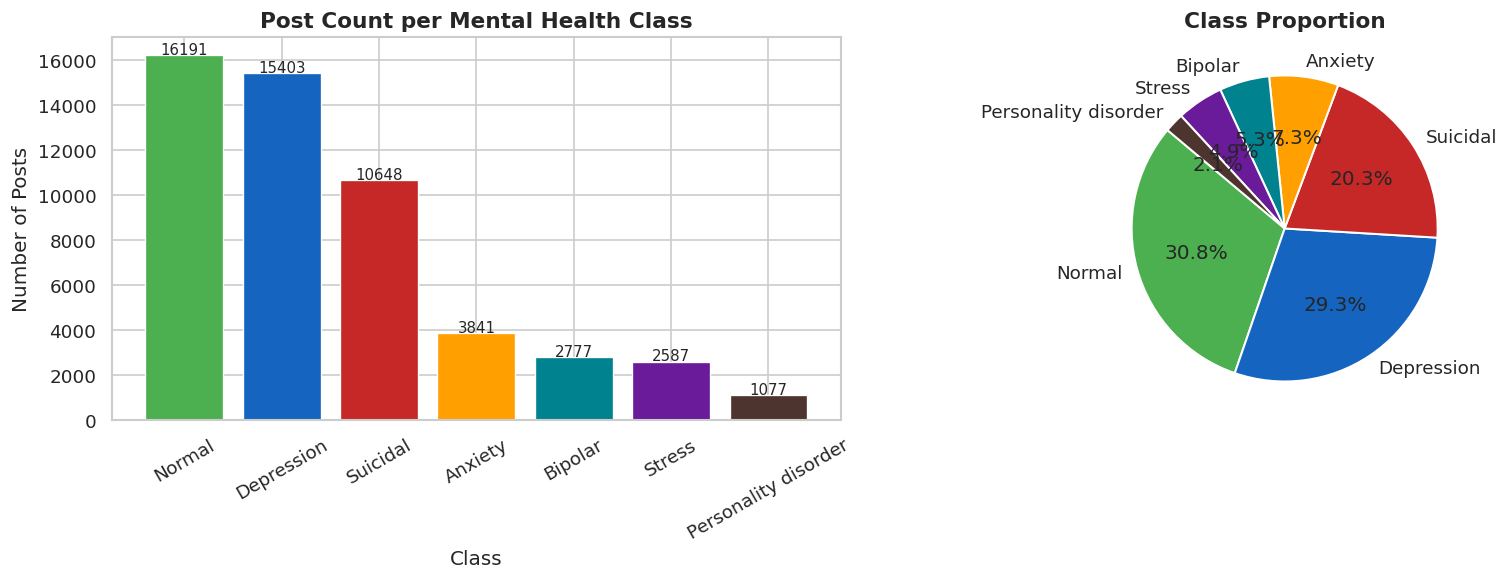

✅ Saved: viz1_class_distribution.png


In [ ]:
CLASS_COLORS = {
    'Normal':                '#4CAF50',
    'Depression':            '#1565C0',
    'Anxiety':               '#FFA000',
    'Suicidal':              '#C62828',
    'Stress':                '#6A1B9A',
    'Bipolar':               '#00838F',
    'Personality disorder':  '#4E342E',
}

counts = df['status'].value_counts()
colors = [CLASS_COLORS.get(c, '#90A4AE') for c in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Post Count per Mental Health Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Posts')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=9)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.2})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUT_PATH}/viz1_class_distribution.png', bbox_inches='tight')
plt.show()
print(' Saved: viz1_class_distribution.png')

### Viz 2 — Word Cloud per Class

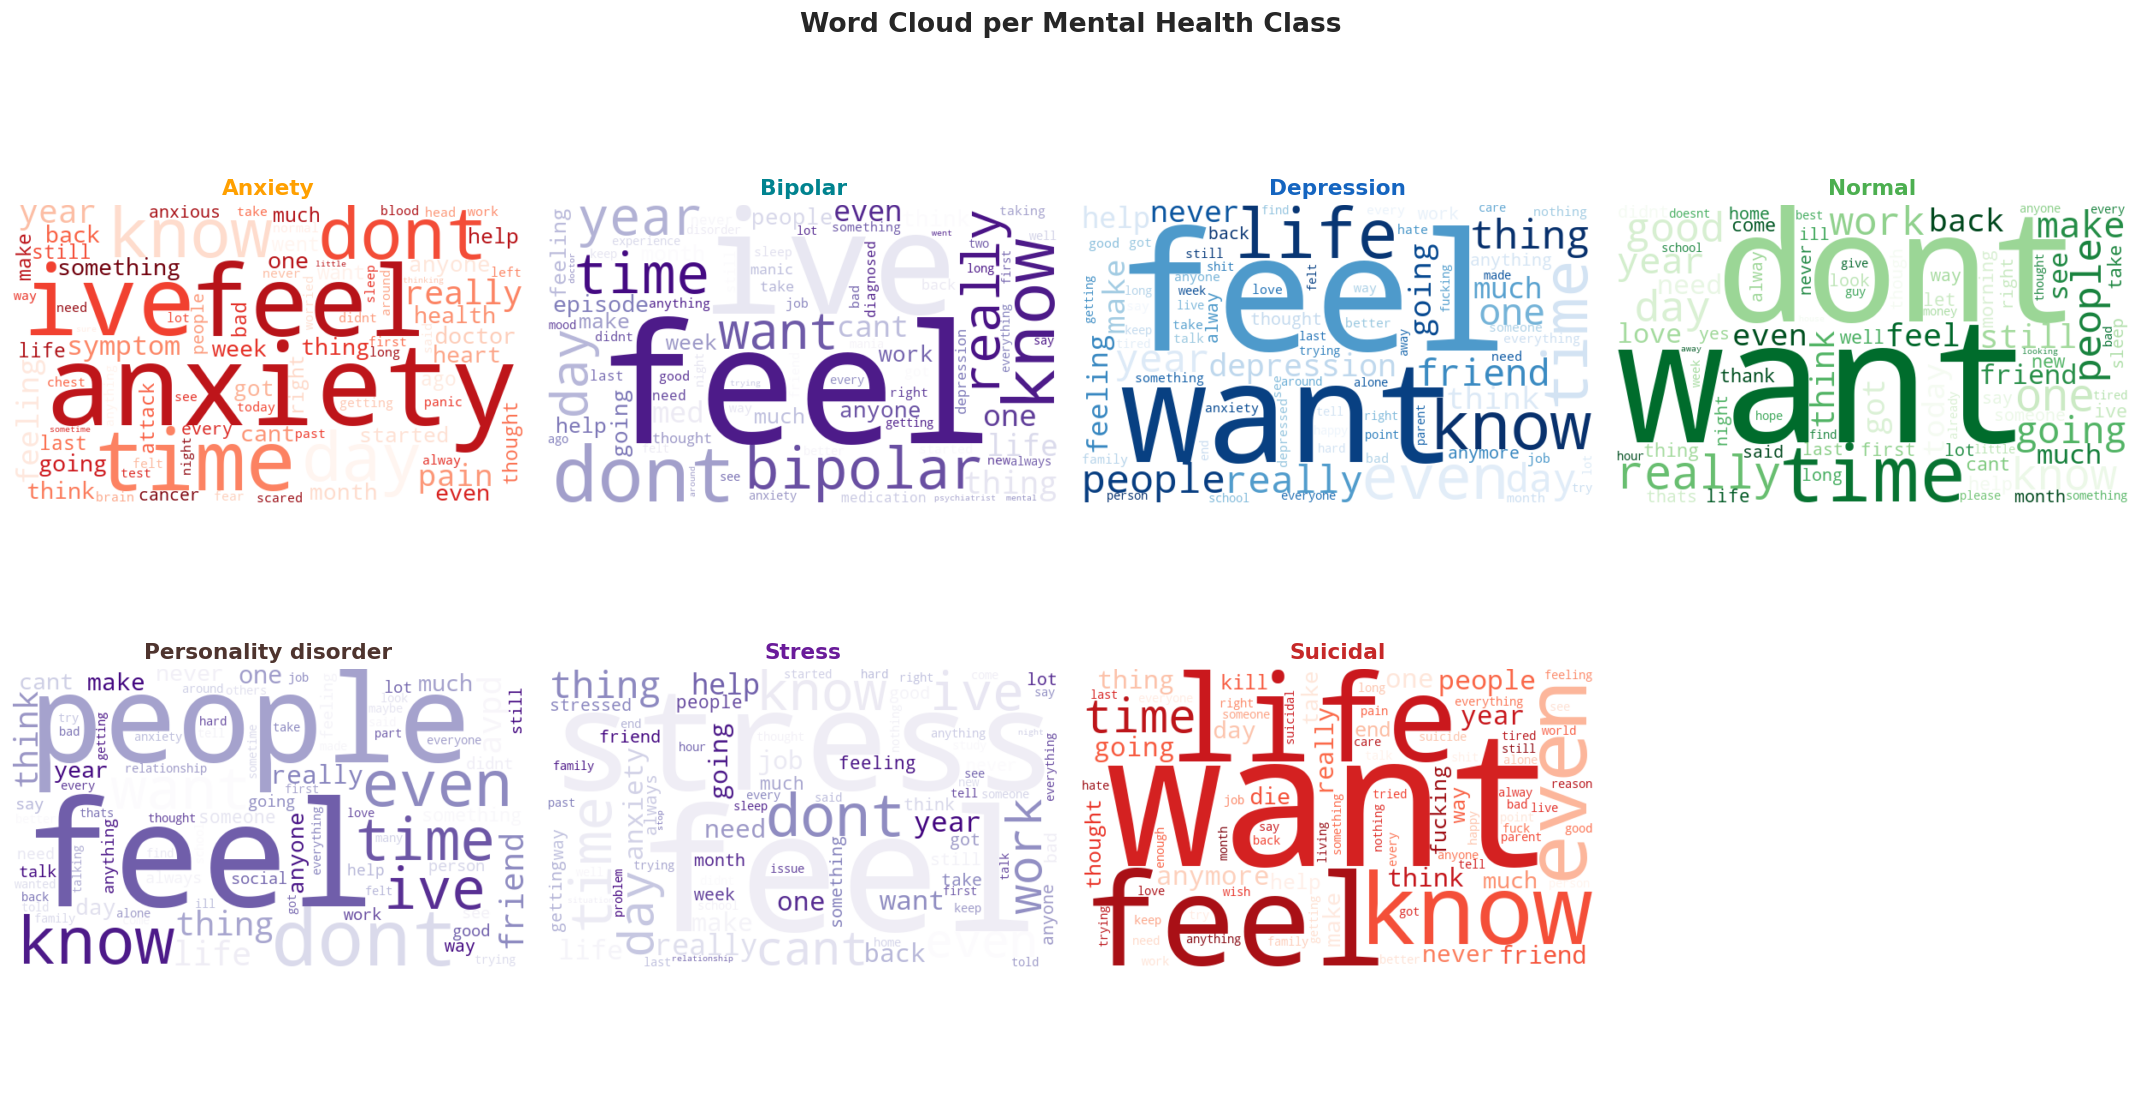

✅ Saved: viz2_wordclouds.png


In [ ]:
classes = df['status'].unique()
n = len(classes)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4.5))
axes = axes.flatten()

for i, cls in enumerate(sorted(classes)):
    text = ' '.join(df[df['status'] == cls]['clean_text'])
    color = CLASS_COLORS.get(cls, '#607D8B')
    wc = WordCloud(
        width=600, height=350,
        background_color='white',
        colormap='Blues' if cls == 'Depression' else
                 'Reds' if cls in ['Suicidal', 'Anxiety'] else
                 'Greens' if cls == 'Normal' else 'Purples',
        max_words=80,
        collocations=False
    ).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(cls, fontsize=13, fontweight='bold', color=color)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Word Cloud per Mental Health Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/viz2_wordclouds.png', bbox_inches='tight')
plt.show()
print('Saved: viz2_wordclouds.png')

### Viz 3 — Text Length Distribution per Class

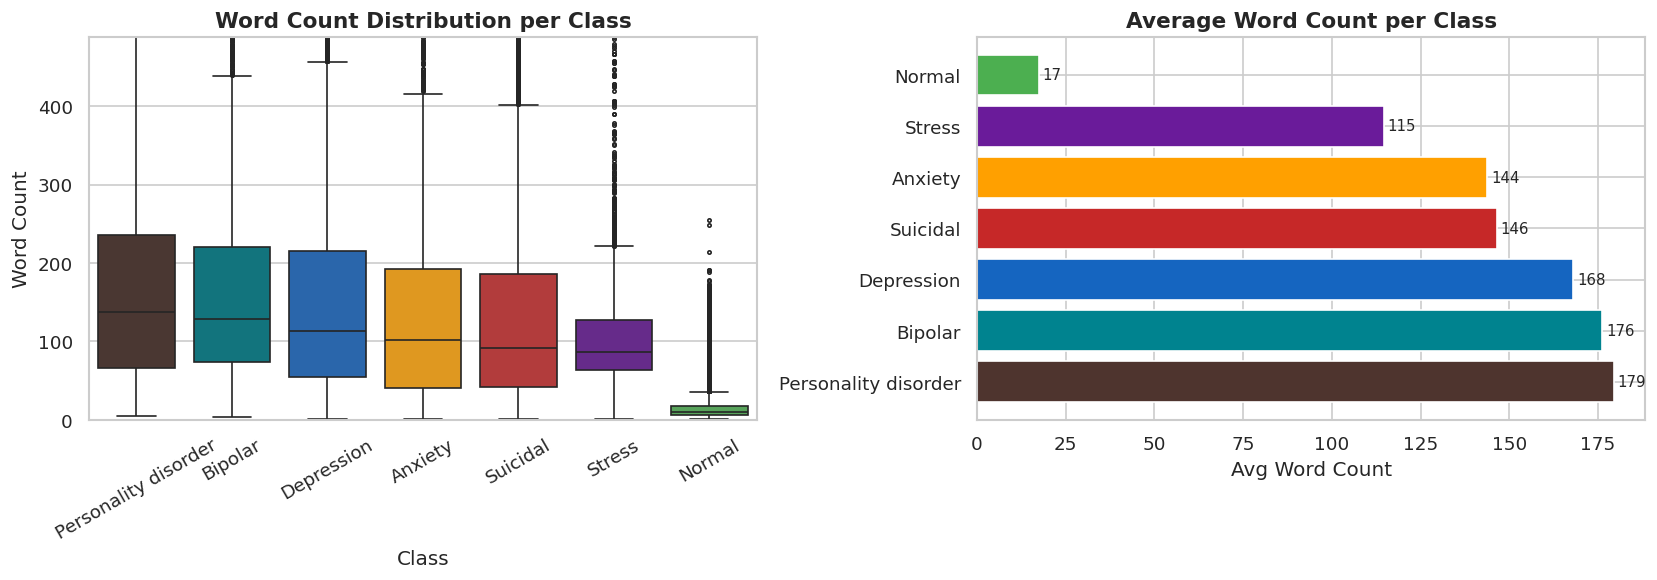

✅ Saved: viz3_text_length.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count boxplot
order = df.groupby('status')['word_count'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='status', y='word_count', order=order,
            palette=[CLASS_COLORS.get(c, '#90A4AE') for c in order],
            ax=axes[0], fliersize=2)
axes[0].set_title('Word Count Distribution per Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Word Count')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(0, df['word_count'].quantile(0.97))

# Average word count bar
avg_wc = df.groupby('status')['word_count'].mean().sort_values(ascending=False)
colors2 = [CLASS_COLORS.get(c, '#90A4AE') for c in avg_wc.index]
axes[1].barh(avg_wc.index, avg_wc.values, color=colors2, edgecolor='white')
axes[1].set_title('Average Word Count per Class', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Avg Word Count')
for i, v in enumerate(avg_wc.values):
    axes[1].text(v + 1, i, f'{v:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUT_PATH}/viz3_text_length.png', bbox_inches='tight')
plt.show()
print('Saved: viz3_text_length.png')

### Viz 4 — Sentiment Score Distribution per Class

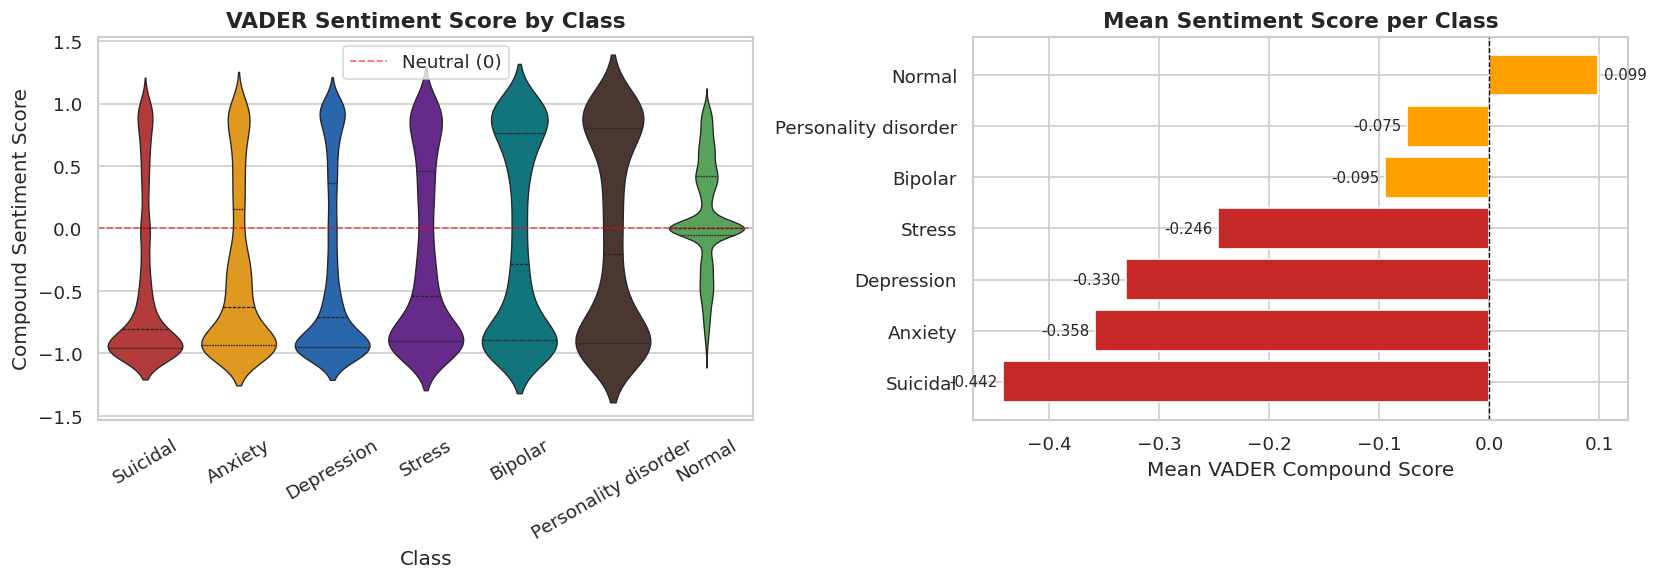

✅ Saved: viz4_sentiment_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violin plot
order2 = df.groupby('status')['sentiment_score'].mean().sort_values().index
sns.violinplot(data=df, x='status', y='sentiment_score', order=order2,
               palette=[CLASS_COLORS.get(c, '#90A4AE') for c in order2],
               ax=axes[0], inner='quartile', linewidth=0.8)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Neutral (0)')
axes[0].set_title('VADER Sentiment Score by Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Compound Sentiment Score')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

# Mean sentiment bar
mean_sent = df.groupby('status')['sentiment_score'].mean().sort_values()
bar_colors = ['#C62828' if v < -0.1 else '#4CAF50' if v > 0.1 else '#FFA000'
              for v in mean_sent.values]
axes[1].barh(mean_sent.index, mean_sent.values, color=bar_colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Mean Sentiment Score per Class', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean VADER Compound Score')
for i, v in enumerate(mean_sent.values):
    axes[1].text(v + 0.005 if v >= 0 else v - 0.005, i,
                 f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUT_PATH}/viz4_sentiment_distribution.png', bbox_inches='tight')
plt.show()
print(' Saved: viz4_sentiment_distribution.png')

## 7. Final Preprocessing & Save

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['status'])

print('Label encoding:')
for cls, lbl in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {lbl} → {cls}')

# Save preprocessed data
df.to_csv(PREP_PATH, index=False)
print(f'\nPreprocessed data saved → data/preprocessed.csv')
print(f'Final shape: {df.shape}')
df[['clean_text', 'status', 'label', 'word_count', 'sentiment_score']].head()

Label encoding:
  0 → Anxiety
  1 → Bipolar
  2 → Depression
  3 → Normal
  4 → Personality disorder
  5 → Stress
  6 → Suicidal

✅ Preprocessed data saved → data/preprocessed.csv
Final shape: (52524, 8)


,clean_text,status,label,word_count,sentiment_score
0,gosh,Anxiety,0,3,0.0000
1,trouble sleeping confused mind restless heart ...,Anxiety,0,10,-0.2263
2,wrong back dear forward doubt stay restless re...,Anxiety,0,14,-0.7351
3,ive shifted focus something else still worried,Anxiety,0,11,-0.4215
4,restless restless month boy mean,Anxiety,0,14,-0.4939


---
<br>

# 🤖 PHASE 2 — NLP Models · ROC Curve · Accuracy Curve · Classification Report
---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_curve, auc
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.calibration import CalibratedClassifierCV
from itertools import cycle

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print(' Libraries loaded')

✅ Libraries loaded


## 1. Load Preprocessed Data

In [14]:
df = pd.read_csv(PREP_PATH)
df = df[df['clean_text'].notna() & (df['clean_text'].str.strip() != '')]

X = df['clean_text']
y = df['status']

CLASSES = sorted(y.unique())
N_CLASSES = len(CLASSES)
print(f'Classes ({N_CLASSES}): {CLASSES}')
print(f'Total samples: {len(df)}')

# Train / test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')

Classes (7): ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']
Total samples: 52524
Train: 42019  |  Test: 10505


## 2. TF-IDF Vectorization

In [15]:
tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'TF-IDF matrix shape (train): {X_train_tfidf.shape}')
print(f'TF-IDF matrix shape (test) : {X_test_tfidf.shape}')

TF-IDF matrix shape (train): (42019, 8000)
TF-IDF matrix shape (test) : (10505, 8000)


## 3. Train Four Classifiers

In [16]:
MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, solver='lbfgs', multi_class='multinomial', random_state=42),
    'Naive Bayes':         MultinomialNB(alpha=0.1),
    'Linear SVM':          CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=42)),
    'Random Forest':       RandomForestClassifier(
        n_estimators=200, max_depth=30, n_jobs=-1, random_state=42),
}

results = {}

for name, model in MODELS.items():
    print(f'Training {name}...', end=' ')
    model.fit(X_train_tfidf, y_train)
    preds   = model.predict(X_test_tfidf)
    acc     = accuracy_score(y_test, preds)
    results[name] = {'model': model, 'preds': preds, 'accuracy': acc}
    print(f'Accuracy = {acc:.4f}')

best_name  = max(results, key=lambda k: results[k]['accuracy'])
best_model = results[best_name]['model']
print(f'\n🏆 Best model: {best_name} ({results[best_name]["accuracy"]:.4f})')

Training Logistic Regression... Accuracy = 0.7496
Training Naive Bayes... Accuracy = 0.6895
Training Linear SVM... Accuracy = 0.7470
Training Random Forest... Accuracy = 0.6541

🏆 Best model: Logistic Regression (0.7496)


## 4. Evaluation — Classification Report

In [ ]:
print(f'=== Classification Report — {best_name} ===\n')
report = classification_report(y_test, results[best_name]['preds'],
                                target_names=CLASSES)
print(report)

# Save report
with open(f'{OUT_PATH}/classification_report.txt', 'w') as f:
    f.write(f'Model: {best_name}\n\n')
    f.write(report)
print(' Saved: classification_report.txt')

=== Classification Report — Logistic Regression ===

                      precision    recall  f1-score   support

             Anxiety       0.81      0.74      0.77       768
             Bipolar       0.89      0.69      0.78       556
          Depression       0.68      0.74      0.71      3081
              Normal       0.83      0.95      0.89      3238
Personality disorder       0.85      0.45      0.59       215
              Stress       0.65      0.39      0.49       517
            Suicidal       0.68      0.60      0.64      2130

            accuracy                           0.75     10505
           macro avg       0.77      0.65      0.69     10505
        weighted avg       0.75      0.75      0.74     10505

✅ Saved: classification_report.txt


## 5. Evaluation — Confusion Matrix

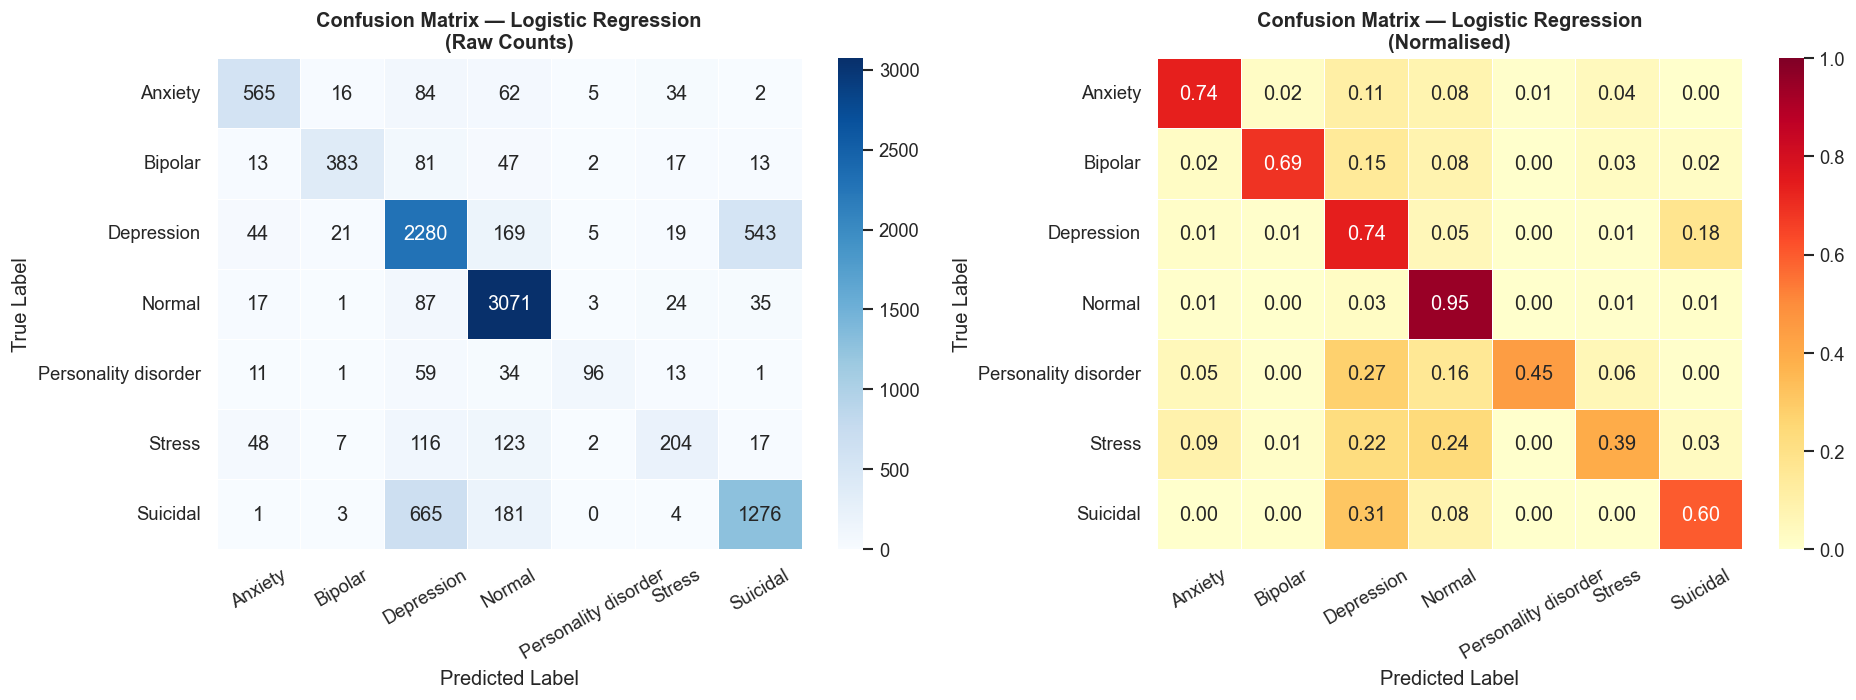

✅ Saved: confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_test, results[best_name]['preds'], labels=CLASSES)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title(f'Confusion Matrix — {best_name}\n(Raw Counts)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].tick_params(axis='x', rotation=30)

# Normalised
sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=CLASSES, yticklabels=CLASSES,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title(f'Confusion Matrix — {best_name}\n(Normalised)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(f'{OUT_PATH}/confusion_matrix.png', bbox_inches='tight')
plt.show()
print(' Saved: confusion_matrix.png')

## 6. Evaluation — ROC Curve (One-vs-Rest, all models)

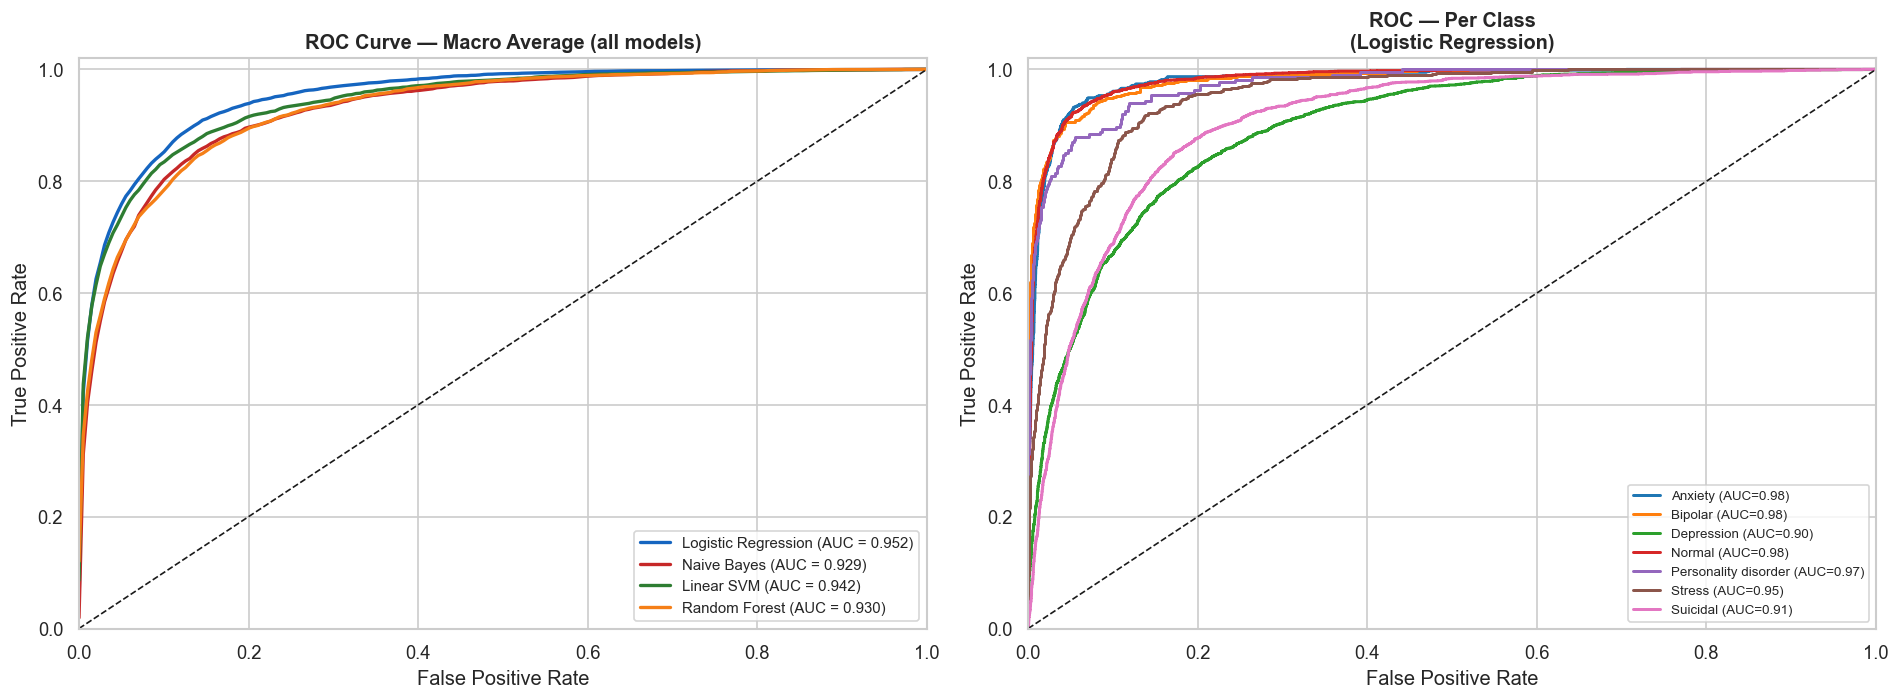

✅ Saved: roc_curve.png


In [ ]:
# Binarise labels for multiclass ROC
le    = LabelEncoder().fit(CLASSES)
y_bin = label_binarize(y_test, classes=CLASSES)

COLORS = ['#1565C0', '#C62828', '#2E7D32', '#F57F17']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: macro-average ROC per model ---
for (name, res), color in zip(results.items(), COLORS):
    proba = res['model'].predict_proba(X_test_tfidf)
    all_fpr = np.linspace(0, 1, 200)
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(N_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
        mean_tpr += np.interp(all_fpr, fpr, tpr)
    mean_tpr /= N_CLASSES
    macro_auc = auc(all_fpr, mean_tpr)
    axes[0].plot(all_fpr, mean_tpr, color=color, lw=2,
                 label=f'{name} (AUC = {macro_auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title('ROC Curve — Macro Average (all models)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

# --- Right: per-class ROC for best model ---
proba_best = best_model.predict_proba(X_test_tfidf)
class_colors = cycle(plt.cm.tab10.colors)
for i, (cls, col) in enumerate(zip(CLASSES, class_colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], proba_best[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, lw=1.8, color=col,
                 label=f'{cls} (AUC={roc_auc:.2f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title(f'ROC — Per Class\n({best_name})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right', fontsize=8)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(f'{OUT_PATH}/roc_curve.png', bbox_inches='tight')
plt.show()
print('Saved: roc_curve.png')

## 7. Evaluation — Accuracy Curve (Learning Curve)

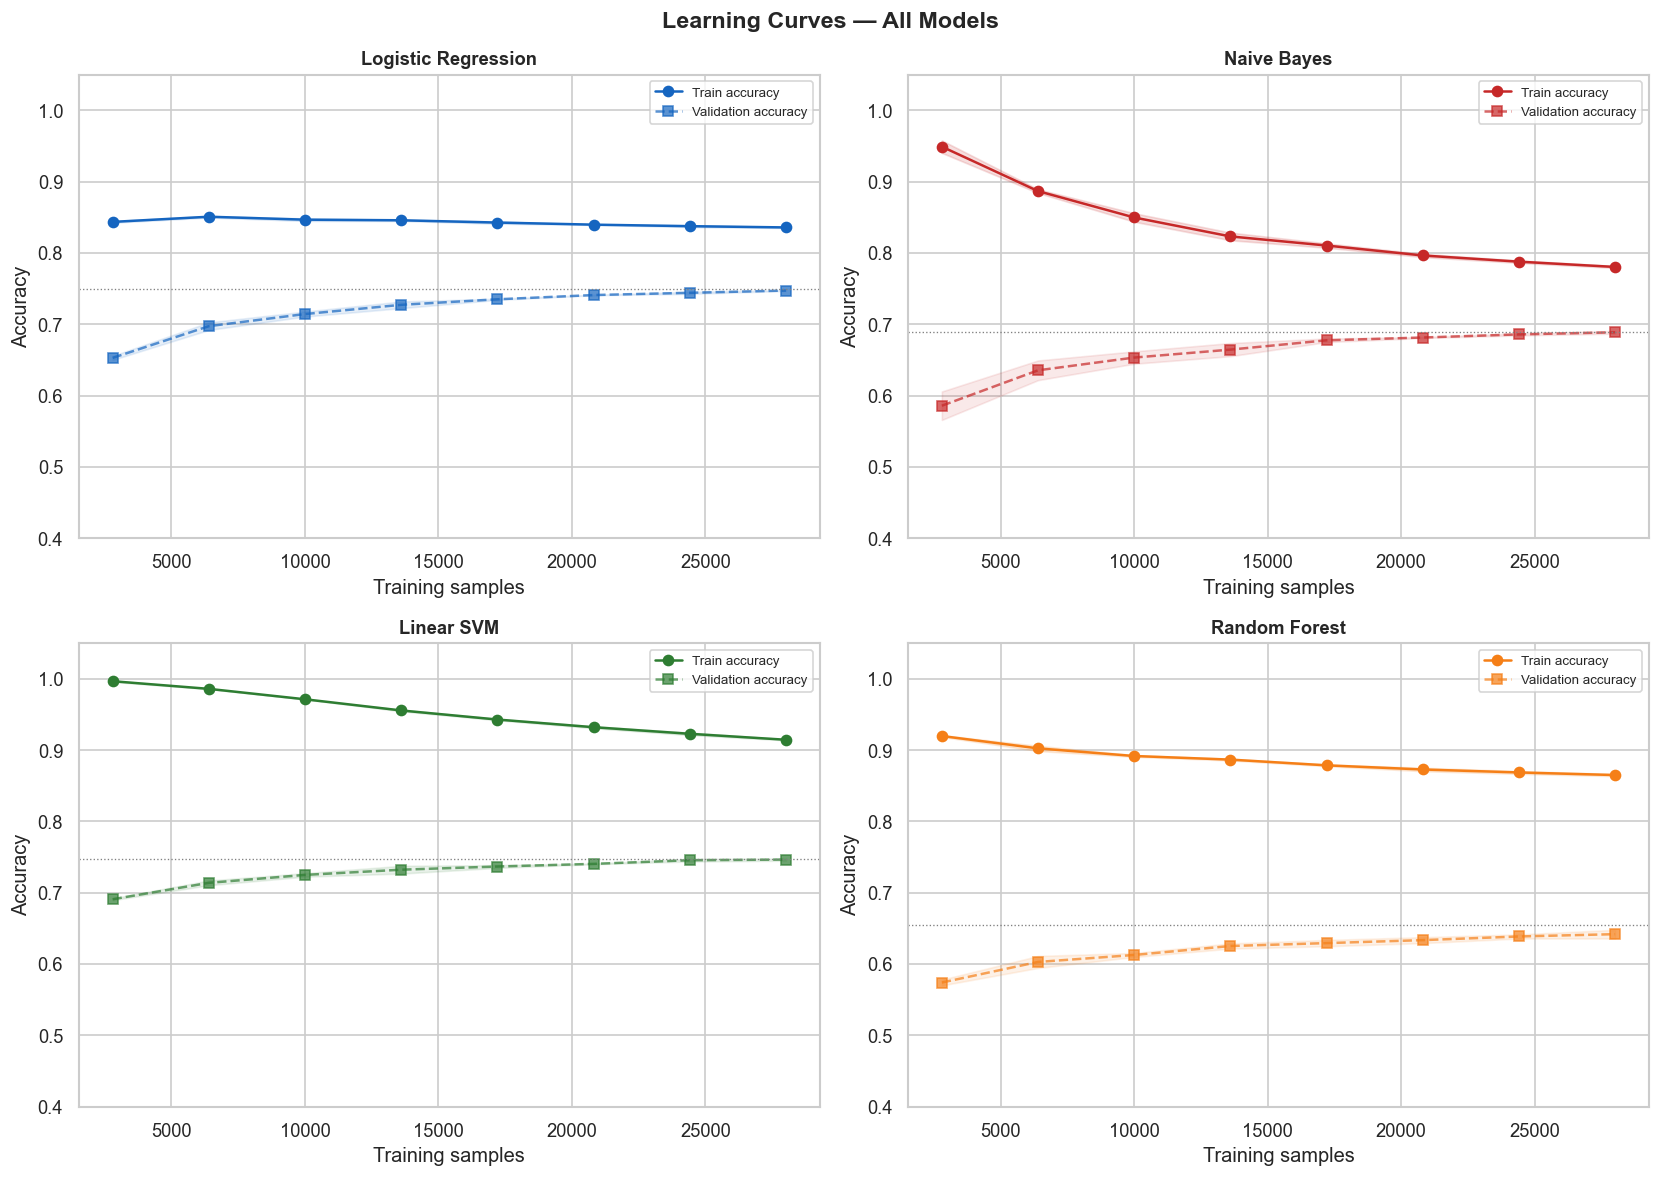

✅ Saved: accuracy_curve.png


In [ ]:
# We compute learning curves for all 4 models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
train_sizes = np.linspace(0.1, 1.0, 8)

for ax, (name, res), color in zip(axes, results.items(), COLORS):
    # Rebuild pipeline for learning curve (TF-IDF + classifier)
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=8000, ngram_range=(1, 2),
                                  sublinear_tf=True, min_df=3)),
        ('clf', res['model'])
    ])
    train_s, train_sc, val_sc = learning_curve(
        pipe, X_train, y_train,
        train_sizes=train_sizes,
        cv=3, scoring='accuracy',
        n_jobs=-1, random_state=42
    )
    tr_mean, tr_std = train_sc.mean(axis=1), train_sc.std(axis=1)
    va_mean, va_std = val_sc.mean(axis=1),   val_sc.std(axis=1)

    ax.plot(train_s, tr_mean, 'o-', color=color, label='Train accuracy')
    ax.fill_between(train_s, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color=color)
    ax.plot(train_s, va_mean, 's--', color=color, alpha=0.7, label='Validation accuracy')
    ax.fill_between(train_s, va_mean - va_std, va_mean + va_std, alpha=0.1, color=color)

    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Training samples')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.4, 1.05)
    ax.legend(fontsize=8)
    ax.axhline(res['accuracy'], color='gray', linewidth=0.8,
               linestyle=':', label=f'Test acc={res["accuracy"]:.3f}')

fig.suptitle('Learning Curves — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/accuracy_curve.png', bbox_inches='tight')
plt.show()
print(' Saved: accuracy_curve.png')

## 8. Model Comparison Summary

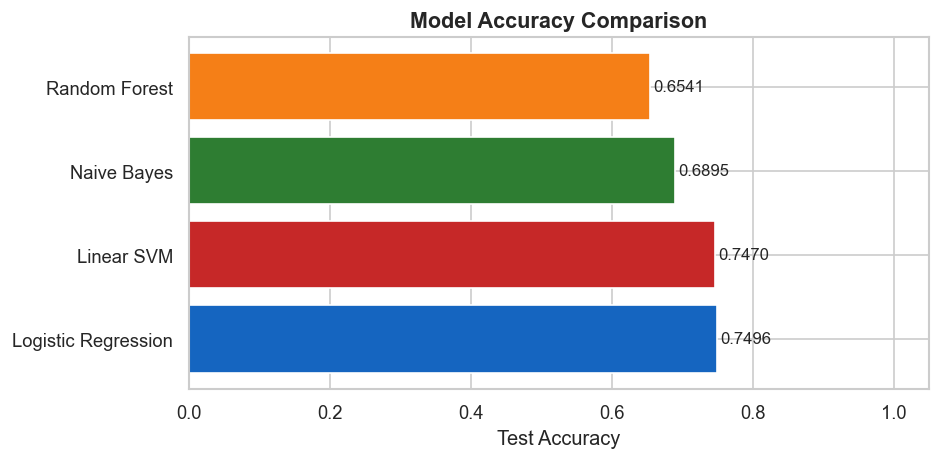

              Model  Accuracy
Logistic Regression  0.749643
         Linear SVM  0.746978
        Naive Bayes  0.689481
      Random Forest  0.654069

✅ Saved: model_comparison.png + model_comparison.csv


In [ ]:
summary = pd.DataFrame([
    {'Model': name, 'Accuracy': res['accuracy']}
    for name, res in results.items()
]).sort_values('Accuracy', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(summary['Model'], summary['Accuracy'],
               color=COLORS[:len(summary)], edgecolor='white')
ax.set_xlim(0, 1.05)
ax.set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('Test Accuracy')
for bar, acc in zip(bars, summary['Accuracy']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{acc:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUT_PATH}/model_comparison.png', bbox_inches='tight')
plt.show()

summary.to_csv(f'{OUT_PATH}/model_comparison.csv', index=False)
print(summary.to_string(index=False))
print(f'\n Saved: model_comparison.png + model_comparison.csv')

## 9. Export Predictions for Tableau

In [ ]:
test_df = df.loc[X_test.index].copy()
test_df['predicted_label'] = results[best_name]['preds']
test_df['correct'] = (test_df['status'] == test_df['predicted_label'])

# Confidence score (max proba)
proba_best = best_model.predict_proba(X_test_tfidf)
test_df['confidence'] = proba_best.max(axis=1).round(4)

export_cols = ['statement', 'clean_text', 'status', 'predicted_label',
               'correct', 'confidence', 'word_count', 'sentiment_score']
test_df[export_cols].to_csv(f'{TAB_PATH}/predictions.csv', index=False)

summary.to_csv(f'{TAB_PATH}/model_summary.csv', index=False)

print(' Tableau exports saved:')
print('   tableau_export/predictions.csv')
print('   tableau_export/model_summary.csv')

✅ Tableau exports saved:
   tableau_export/predictions.csv
   tableau_export/model_summary.csv


## 10. Save Trained Model to Disk
> This saves your model permanently so you never need to retrain again.

In [ ]:
import joblib

# Save the trained model and TF-IDF vectorizer to disk
# Next time you open Jupyter you can load these directly — no retraining needed!
joblib.dump(best_model, os.path.join(MODEL_PATH, 'best_model.pkl'))
joblib.dump(tfidf,      os.path.join(MODEL_PATH, 'tfidf_vectorizer.pkl'))

print(' Model saved successfully!')
print(f'   best_model.pkl       → {os.path.join(MODEL_PATH, "best_model.pkl")}')
print(f'   tfidf_vectorizer.pkl → {os.path.join(MODEL_PATH, "tfidf_vectorizer.pkl")}')
print()
print('💡 To load later without retraining:')
print('   import joblib')
print('   model = joblib.load(os.path.join(MODEL_PATH, "best_model.pkl"))')
print('   tfidf = joblib.load(os.path.join(MODEL_PATH, "tfidf_vectorizer.pkl"))')


✅ Model saved successfully!
   best_model.pkl       → C:\Users\Prajna\Desktop\PJ\mental_health_nlp\model\best_model.pkl
   tfidf_vectorizer.pkl → C:\Users\Prajna\Desktop\PJ\mental_health_nlp\model\tfidf_vectorizer.pkl

💡 To load later without retraining:
   import joblib
   model = joblib.load(os.path.join(MODEL_PATH, "best_model.pkl"))
   tfidf = joblib.load(os.path.join(MODEL_PATH, "tfidf_vectorizer.pkl"))


## 11. Predict Any Text — Live Demo
> Type any sentence below and the model will predict the mental health category.

In [ ]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

_stop = set(stopwords.words('english'))
_lem  = WordNetLemmatizer()

def clean_for_predict(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = [_lem.lemmatize(w) for w in text.split()
              if w not in _stop and len(w) > 2]
    return ' '.join(tokens)

def predict_mental_health(text):
    print(f'\nInput: "{text[:80]}"')
    print('-' * 50)
    cleaned   = clean_for_predict(text)
    vec       = tfidf.transform([cleaned])
    pred      = best_model.predict(vec)[0]
    proba     = best_model.predict_proba(vec)[0]
    confidence = proba.max() * 100
    print(f'  Prediction  : {pred}')
    print(f' Confidence  : {confidence:.1f}%')
    print(f'\n All class probabilities:')
    for cls, prob in sorted(zip(best_model.classes_, proba), key=lambda x: -x[1]):
        bar = '█' * int(prob * 25)
        print(f'   {cls:25s} {bar:<25s} {prob*100:5.1f}%')

# ── Test with sample sentences ──────────────────────────────────────────────
predict_mental_health("I feel completely empty and hopeless, nothing makes me happy anymore")
predict_mental_health("Had a wonderful day today, feeling really grateful and positive!")
predict_mental_health("I can't stop worrying about everything, my heart races all the time")
predict_mental_health("My mood swings are extreme, yesterday I felt on top of the world")

# ── Type YOUR OWN text here ──────────────────────────────────────────────────
# predict_mental_health("your text here")



📝 Input: "I feel completely empty and hopeless, nothing makes me happy anymore"
--------------------------------------------------
🏷️  Prediction  : Depression
📊 Confidence  : 75.9%

📈 All class probabilities:
   Depression                ██████████████████         75.9%
   Suicidal                  ████                       18.4%
   Normal                    █                           4.5%
   Stress                                                0.4%
   Personality disorder                                  0.3%
   Bipolar                                               0.3%
   Anxiety                                               0.2%

📝 Input: "Had a wonderful day today, feeling really grateful and positive!"
--------------------------------------------------
🏷️  Prediction  : Normal
📊 Confidence  : 77.5%

📈 All class probabilities:
   Normal                    ███████████████████        77.5%
   Depression                ███                        12.7%
   Anxiety                  

## 12.  Load Saved Model (Skip Retraining Next Time)
> Run ONLY this cell next time instead of retraining everything from scratch.

In [ ]:
# ============================================================
# NEXT TIME: Run ONLY this cell to load the saved model
# You can then directly use predict_mental_health() function
# ============================================================
import joblib, os

# Make sure BASE and MODEL_PATH are set (run the first setup cell)
best_model = joblib.load(os.path.join(MODEL_PATH, 'best_model.pkl'))
tfidf      = joblib.load(os.path.join(MODEL_PATH, 'tfidf_vectorizer.pkl'))

print(' Model loaded from disk — ready to predict!')
print(f'   Model type : {type(best_model).__name__}')
print('   No retraining needed!')


✅ Model loaded from disk — ready to predict!
   Model type : LogisticRegression
   No retraining needed!


---
<br>

#  PHASE 3 — Tableau Export & Dashboard Guide
---

In [26]:
# Phase 3 — reload predictions CSV for Tableau aggregation
import pandas as pd
import numpy as np
import os

_pred_df   = pd.read_csv(os.path.join(TAB_PATH, 'predictions.csv'))
_model_df  = pd.read_csv(os.path.join(TAB_PATH, 'model_summary.csv'))
print(f'Predictions shape : {_pred_df.shape}')
_pred_df.head()


Predictions shape : (10505, 8)


,statement,clean_text,status,predicted_label,correct,confidence,word_count,sentiment_score
0,i've enjoyed conversing with you.,ive enjoyed conversing,Normal,Normal,True,0.9343,5,0.5106
1,Have been on the bathroom floor unable to brea...,bathroom floor unable breathe cry hard worth m...,Depression,Suicidal,False,0.5414,28,-0.8989
2,happy birthday jaime loveyou lt officially scr...,happy birthday jaime loveyou officially screwe...,Normal,Normal,True,0.8849,19,0.1027
3,matched with a guy on a dating app we went on ...,matched guy dating app went date hooked couple...,Depression,Depression,True,0.5325,145,0.7975
4,Does anyone else experience different types of...,anyone else experience different type personal...,Bipolar,Bipolar,True,0.7913,193,-0.8236


## 1. Prepare Aggregated Tables for Tableau

In [ ]:
# --- Table 1: Class-level summary ---
class_summary = _pred_df.groupby('status').agg(
    total_posts    = ('statement', 'count'),
    avg_sentiment  = ('sentiment_score', 'mean'),
    avg_word_count = ('word_count', 'mean'),
    correct_preds  = ('correct', 'sum')
).reset_index()
class_summary['accuracy_per_class'] = (
    class_summary['correct_preds'] / class_summary['total_posts']
).round(4)
class_summary['pct_of_total'] = (
    class_summary['total_posts'] / class_summary['total_posts'].sum() * 100
).round(2)

class_summary.to_csv(f'{TAB_PATH}/class_summary.csv', index=False)
print(' Saved: class_summary.csv')
class_summary

✅ Saved: class_summary.csv


,status,total_posts,avg_sentiment,avg_word_count,correct_preds,accuracy_per_class,pct_of_total
0,Anxiety,768,-0.329458,155.839844,565,0.7357,7.31
1,Bipolar,556,-0.098156,159.061151,383,0.6888,5.29
2,Depression,3081,-0.323397,167.477442,2280,0.7400,29.33
3,Normal,3238,0.104630,17.654416,3071,0.9484,30.82
4,Personality disorder,215,-0.112893,174.279070,96,0.4465,2.05
5,Stress,517,-0.207829,123.978723,204,0.3946,4.92
6,Suicidal,2130,-0.447098,139.709859,1276,0.5991,20.28


In [ ]:
# --- Table 2: Sentiment buckets ---
def sentiment_bucket(score):
    if score > 0.05:  return 'Positive'
    elif score < -0.05: return 'Negative'
    else: return 'Neutral'

_pred_df['sentiment_bucket'] = _pred_df['sentiment_score'].apply(sentiment_bucket)
sent_cross = _pred_df.groupby(['status', 'sentiment_bucket']).size().reset_index(name='count')
sent_cross.to_csv(f'{TAB_PATH}/sentiment_by_class.csv', index=False)
print(' Saved: sentiment_by_class.csv')
sent_cross.head(10)

✅ Saved: sentiment_by_class.csv


,status,sentiment_bucket,count
0,Anxiety,Negative,531
1,Anxiety,Neutral,15
2,Anxiety,Positive,222
3,Bipolar,Negative,294
4,Bipolar,Neutral,15
5,Bipolar,Positive,247
6,Depression,Negative,2068
7,Depression,Neutral,66
8,Depression,Positive,947
9,Normal,Negative,799


In [ ]:
# --- Table 3: Word count buckets ---
_pred_df['length_bucket'] = pd.cut(_pred_df['word_count'],
    bins=[0, 50, 150, 300, 600, 10000],
    labels=['Very short (<50)', 'Short (50-150)',
            'Medium (150-300)', 'Long (300-600)', 'Very long (600+)'])

len_cross = _pred_df.groupby(['status', 'length_bucket']).size().reset_index(name='count')
len_cross.to_csv(f'{TAB_PATH}/length_by_class.csv', index=False)
print(' Saved: length_by_class.csv')
len_cross.head(10)

✅ Saved: length_by_class.csv


,status,length_bucket,count
0,Anxiety,Very short (<50),211
1,Anxiety,Short (50-150),284
2,Anxiety,Medium (150-300),174
3,Anxiety,Long (300-600),73
4,Anxiety,Very long (600+),26
5,Bipolar,Very short (<50),76
6,Bipolar,Short (50-150),259
7,Bipolar,Medium (150-300),154
8,Bipolar,Long (300-600),60
9,Bipolar,Very long (600+),7


## 2. Tableau Dashboard — Build Instructions

### Files to connect in Tableau Public
Connect all 5 CSVs from `tableau_export/` folder:
- `predictions.csv` — main data source
- `class_summary.csv` — for KPI tiles and class-level charts
- `model_summary.csv` — for model comparison chart
- `sentiment_by_class.csv` — for sentiment stacked bar
- `length_by_class.csv` — for word length chart

---

### Sheet 1 — Class Distribution (Bar + Pie)
```
Source : class_summary.csv
Chart  : Bar chart
Columns: Status
Rows   : Total Posts
Color  : Status
Label  : Pct Of Total
+ Duplicate as Pie chart → Angle = Total Posts
```

### Sheet 2 — Average Sentiment per Class
```
Source : class_summary.csv
Chart  : Horizontal bar
Rows   : Status (sort by Avg Sentiment ascending)
Columns: Avg Sentiment
Color  : Avg Sentiment (diverging Red–White–Green)
Reference line: 0
```

### Sheet 3 — Sentiment Breakdown Stacked Bar
```
Source : sentiment_by_class.csv
Chart  : Stacked bar
Columns: Status
Rows   : Count
Color  : Sentiment Bucket (Positive=green, Neutral=gray, Negative=red)
```

### Sheet 4 — Model Accuracy Comparison
```
Source : model_summary.csv
Chart  : Horizontal bar
Rows   : Model (sort by Accuracy desc)
Columns: Accuracy
Color  : Model
Label  : Accuracy (format 0.00%)
Reference line: 0.80
```

### Sheet 5 — Per-Class Accuracy
```
Source : class_summary.csv
Chart  : Bullet / bar chart
Rows   : Status
Columns: Accuracy Per Class
Color  : Accuracy Per Class (sequential blue)
```

### KPI Tiles (Text charts)
```
KPI 1: Total Posts       → SUM(total_posts) from class_summary
KPI 2: Best Model Acc    → MAX(Accuracy) from model_summary
KPI 3: Classes           → COUNTD(Status)
KPI 4: Avg Sentiment     → AVG(avg_sentiment) from class_summary
```

### Dashboard Layout
```
+---KPI1---+---KPI2---+---KPI3---+---KPI4---+
|      Sheet 1 (Bar)      | Sheet 4 (Models) |
|      Sheet 2 (Sentiment)| Sheet 5 (Acc)    |
|      Sheet 3 (Stacked)                     |
+--------------------------------------------+
Add: Status filter (applies to all sheets)
```

**Publish** → Tableau Public → copy shareable link for project report.

In [ ]:
import os
print(' tableau_export/ contents:')
for f in sorted(os.listdir(TAB_PATH)):
    size = os.path.getsize(os.path.join(TAB_PATH, f))
    print(f'  {f:40s}  {size/1024:.1f} KB')
print('\n Phase 3 complete — upload CSVs to Tableau Public!')


📁 tableau_export/ contents:
  class_summary.csv                         0.6 KB
  length_by_class.csv                       1.1 KB
  model_summary.csv                         0.1 KB
  predictions.csv                           9801.8 KB
  sentiment_by_class.csv                    0.5 KB

✅ Phase 3 complete — upload CSVs to Tableau Public!


In [ ]:
import os

print("=== PROJECT STATUS CHECK ===\n")

# Check model saved
model_file = os.path.join(MODEL_PATH, 'best_model.pkl')
tfidf_file = os.path.join(MODEL_PATH, 'tfidf_vectorizer.pkl')
print("MODEL FILES:")
print(f"  best_model.pkl       : {' EXISTS' if os.path.exists(model_file) else ' MISSING'}")
print(f"  tfidf_vectorizer.pkl : {' EXISTS' if os.path.exists(tfidf_file) else ' MISSING'}")

# Check outputs
print("\nOUTPUT CHARTS:")
for f in ['viz1_class_distribution.png','viz2_wordclouds.png',
          'viz3_text_length.png','viz4_sentiment_distribution.png',
          'roc_curve.png','confusion_matrix.png','accuracy_curve.png']:
    exists = os.path.exists(os.path.join(OUT_PATH, f))
    print(f"  {f:45s} {'EXISTS' if exists else 'NOT FOUND'}")

# Check tableau
print("\nTABLEAU FILES:")
for f in ['predictions.csv','class_summary.csv','model_summary.csv',
          'sentiment_by_class.csv','length_by_class.csv']:
    exists = os.path.exists(os.path.join(TAB_PATH, f))
    print(f"  {f:35s} {'EXISTS' if exists else 'NOT FOUND'}")

=== PROJECT STATUS CHECK ===

MODEL FILES:
  best_model.pkl       : ✅ EXISTS
  tfidf_vectorizer.pkl : ✅ EXISTS

OUTPUT CHARTS:
  viz1_class_distribution.png                   ✅
  viz2_wordclouds.png                           ✅
  viz3_text_length.png                          ✅
  viz4_sentiment_distribution.png               ✅
  roc_curve.png                                 ✅
  confusion_matrix.png                          ✅
  accuracy_curve.png                            ✅

TABLEAU FILES:
  predictions.csv                     ✅
  class_summary.csv                   ✅
  model_summary.csv                   ✅
  sentiment_by_class.csv              ✅
  length_by_class.csv                 ✅
